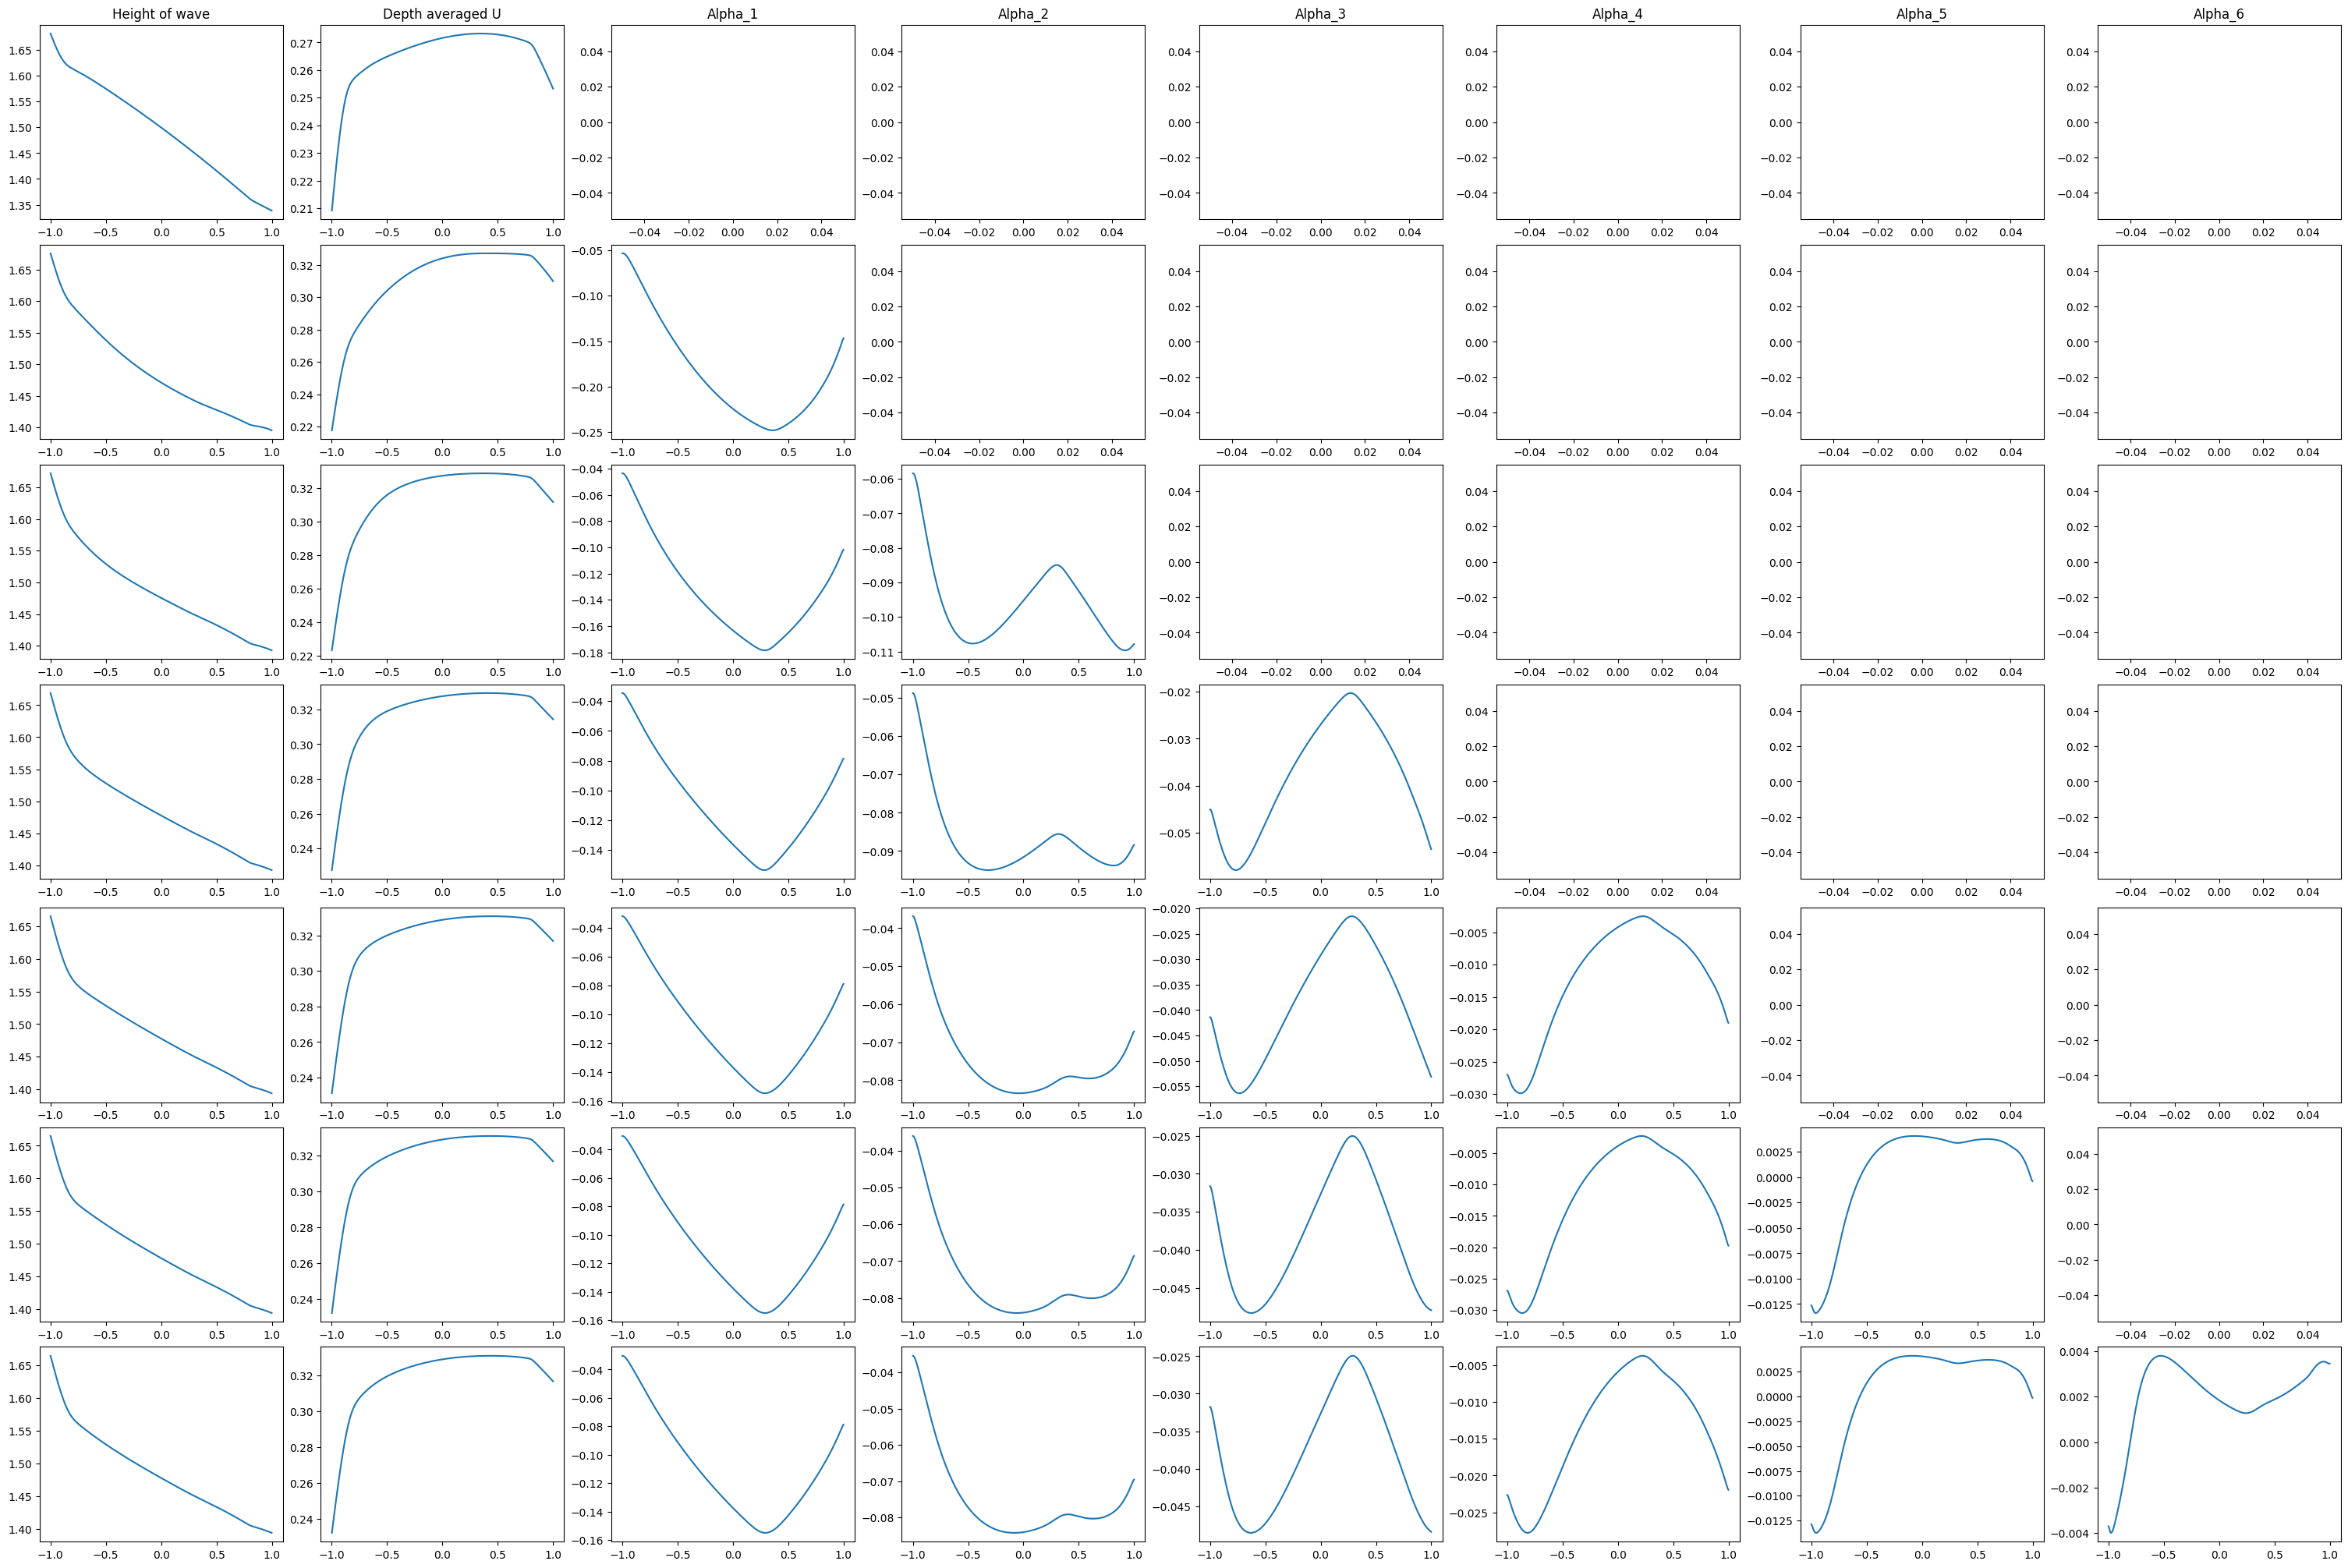

In [ ]:
plot_names = ["Height of wave", "Depth averaged U"]
for i in range(1, order+1):
    plot_names.append(f"Alpha_{i}")

# we need 1 extra plot for order 0 to order (included)
# We need an extra 2 plots per row for height, and u_avg
fig, axs = plt.subplots(order+1, order+2, 
                        figsize=(30,20),layout="constrained")

for row in range(order+1):
    moment_i = data[data[:,0]==row]   

    for col in range(order+2):
        axs[row,col].plot(moment_i[:,1], moment_i[:,col+2])
        
        if row == 0:
            axs[0,col].set_title(plot_names[col])


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from itertools import product

In [17]:
data_path = Path(os.getcwd()) / "Data-processing/Results/Omar"

data = pd.read_csv(data_path / "01-data_stacked.csv")
data_time = pd.read_csv(data_path / "02-time_stacked.csv")
errors = pd.read_csv(data_path / "03-errors.csv")

resolution_list = errors["Resolution"].unique()
plant_h_list = errors["Plant Height"].unique()      

In [21]:
resolution_list

array([1000., 2000., 5000.])

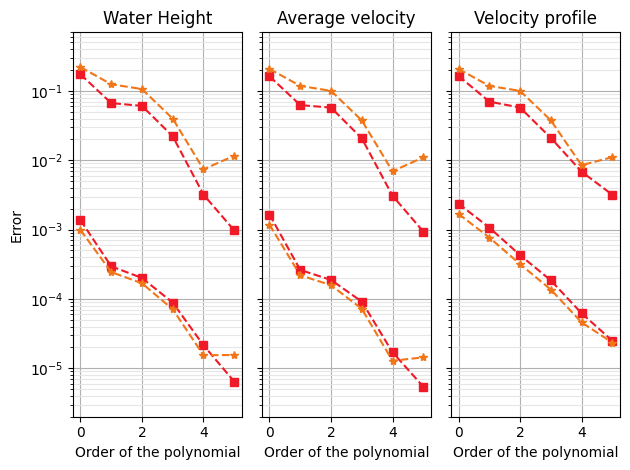

In [ ]:
resolution_list = errors["Resolution"].unique()
plant_h_list = errors["Plant Height"].unique()        

# Error vs resolution

symbol_map = {100.0:"^", 500.0:"2", 1000.0:"s", 2000.0:"*", 5000.0:"o"}
color_map = {0.0:"#F01927", 0.25:"#F07619", 0.5:"#F0E219", 0.75:"#19F0E2", 1.0:"#1927F0"}
# color_map = {0.0:"#d9fdf8", 0.25:"#18f4d6", 0.5:"#F0E219", 0.75:"#09b39c", 1.0:"#056659"}

fig, axs = plt.subplots(1, 3, sharey=True)
for resolution in resolution_list:
    
    mask = (errors["Plant Height"] == 1.0) & (errors["Resolution"] == resolution)

    axs[0].plot(errors.loc[mask,"Order"], errors.loc[mask, "L2 Water Height"], 
                   marker=symbol_map[resolution],
                   linestyle='--',
                   label=f"L2 Res {resolution}",
                   alpha=0.75)

    axs[1].plot(errors.loc[mask,"Order"], errors.loc[mask, "L2 Average Velocity"], 
                   marker=symbol_map[resolution],
                   linestyle='--',
                   label=f"L2 Res {resolution}",
                   alpha=0.75)

    axs[2].errorbar(errors.loc[mask,"Order"], errors.loc[mask, "L2 U profile"], 
                      yerr=errors.loc[mask,"L2 std U profile"],
                      marker=symbol_map[resolution],
                      linestyle='--',
                      label=f"L2 Res {resolution}",
                      alpha=0.75)
    
    axs[0].plot(errors.loc[mask,"Order"], errors.loc[mask, "LInf Water Height"], 
                   marker=symbol_map[resolution],
                   linestyle='--',
                   label=f"LInf Res {resolution}",
                   alpha=0.75)

    axs[1].plot(errors.loc[mask,"Order"], errors.loc[mask, "LInf Average Velocity"], 
                   marker=symbol_map[resolution],
                   linestyle='--',
                   label=f"LInf Res {resolution}",
                   alpha=0.75)

    axs[2].errorbar(errors.loc[mask,"Order"], errors.loc[mask, "LInf U profile"], 
                      yerr=errors.loc[mask,"L2 std U profile"],
                      marker=symbol_map[resolution],
                      linestyle='--',
                      label=f"LInfRes {resolution}",
                      alpha=0.75)


    axs[0].set_title("Water Height")
    axs[1].set_title("Average velocity")
    axs[2].set_title("Velocity profile")
    axs[0].set_ylabel("Error")
    axs[0].set_xlabel("Order of the polynomial")
    axs[1].set_xlabel("Order of the polynomial")
    axs[2].set_xlabel("Order of the polynomial")

for ax in axs.flatten():
    ax.set_yscale("log")
    ax.grid()
    ax.grid(which="minor", color="0.9")
    ax.set_ylim(2e-6,7e-1)
fig.tight_layout()


In [ ]:
# Error vs resolution

symbol_map = {100.0:"^", 500.0:"2", 1000.0:"s", 2000.0:"*", 5000.0:"o"}
color_map = {0.0:"#F01927", 0.25:"#F07619", 0.5:"#F0E219", 0.75:"#19F0E2", 1.0:"#1927F0"}
color_map_res = {100.0:"r", 500.0:"r", 1000.0:"#F01927", 2000.0:"#F07619", 5000.0:"#F0E219"}
# color_map = {0.0:"#d9fdf8", 0.25:"#18f4d6", 0.5:"#F0E219", 0.75:"#09b39c", 1.0:"#056659"}

fig, axs = plt.subplots(1, 3, sharey=True)
for resolution in resolution_list:
    
    mask = (errors["Plant Height"] == 1.0) & (errors["Resolution"] == resolution)

    axs[0].plot(errors.loc[mask,"Order"], errors.loc[mask, "L2 Water Height"], 
                   marker=symbol_map[resolution],
                   color=color_map_res[resolution],
                   linestyle='--',
                   label=f"L2 Res {resolution}",
                )

    axs[1].plot(errors.loc[mask,"Order"], errors.loc[mask, "L2 Average Velocity"], 
                   marker=symbol_map[resolution],
                   color=color_map_res[resolution],
                   linestyle='--',
                   label=f"L2 Res {resolution}",
                )

    axs[2].errorbar(errors.loc[mask,"Order"], errors.loc[mask, "L2 U profile"], 
                      yerr=errors.loc[mask,"L2 std U profile"],
                      marker=symbol_map[resolution],
                      color=color_map_res[resolution],
                      linestyle='--',
                      label=f"L2 Res {resolution}",
                )
    
    axs[0].plot(errors.loc[mask,"Order"], errors.loc[mask, "LInf Water Height"], 
                   marker=symbol_map[resolution],
                   color=color_map_res[resolution],
                   linestyle='--',
                   label=f"LInf Res {resolution}",
                )

    axs[1].plot(errors.loc[mask,"Order"], errors.loc[mask, "LInf Average Velocity"], 
                   marker=symbol_map[resolution],
                   color=color_map_res[resolution],
                   linestyle='--',
                   label=f"LInf Res {resolution}"
                )
    #TODO: Show the error bar
    axs[2].errorbar(errors.loc[mask,"Order"], errors.loc[mask, "LInf U profile"], 
                      yerr=errors.loc[mask,"L2 std U profile"],
                      marker=symbol_map[resolution],
                      color=color_map_res[resolution],
                      linestyle='--',
                      label=f"LInf Res {resolution}",
                )


    axs[0].set_title("Water Height")
    axs[1].set_title("Average velocity")
    axs[2].set_title("Velocity profile")
    axs[0].set_ylabel("Error")
    axs[0].set_xlabel("Order of the polynomial")
    axs[1].set_xlabel("Order of the polynomial")
    axs[2].set_xlabel("Order of the polynomial")

for ax in axs.flatten():
    ax.set_yscale("log")
    ax.grid()
    ax.grid(which="minor", color="0.9")
    ax.set_ylim(2e-6,7e-1)
fig.tight_layout()

In [ ]:
symbol_map = {100.0:"^", 500.0:"2", 1000.0:"s", 2000.0:"*", 5000.0:"o"}
color_map = {0.0:"#F01927", 0.25:"#F07619", 0.5:"#F0E219", 0.75:"#19F0E2", 1.0:"#1927F0"}
# color_map = {0.0:"#d9fdf8", 0.25:"#18f4d6", 0.5:"#F0E219", 0.75:"#09b39c", 1.0:"#056659"}

fig, axs = plt.subplots(1,3)
counter = 0
for resolution in resolution_list:

    for height in plant_h_list:
    
        mask = (errors["Plant Height"] == height) & (errors["Resolution"] == resolution)
        
        for ax in axs.flatten():

            ax.plot(errors.loc[mask,"Order"], data_time.loc[mask, "Time"], 
                        marker=symbol_map[resolution],
                        linestyle='--',
                        label=f"L2 Res {resolution}",
                        alpha=0.75)



        axs[0].set_title("Water Height")
        axs[1].set_title("Average velocity")
        axs[2].set_title("Velocity profile")
        axs[0].set_ylabel("Error")
        axs[0].set_xlabel("Order of the polynomial")
        axs[1].set_xlabel("Order of the polynomial")
        axs[2].set_xlabel("Order of the polynomial")

for ax in axs.flatten():
    ax.set_yscale("log")
    ax.grid()
    ax.grid(which="minor", color="0.9")
    ax.set_ylim(2e-6,7e-1)
fig.tight_layout()